### Import required packages

In [1]:
!pip install opencv-python-headless

In [2]:
!pip install pydot

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
import seaborn as sns
from skimage import feature
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
%matplotlib inline
print(tf.__version__)

2026-03-20 02:28:46.326962: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.18.0


### Unzip dataset

In [4]:
!unzip student_25717671.zip

Archive:  student_25717671.zip
   creating: student_25717671/(/
  inflating: student_25717671/(/(_100175.jpg  
  inflating: student_25717671/(/(_100286.jpg  
  inflating: student_25717671/(/(_100646.jpg  
  inflating: student_25717671/(/(_101159.jpg  
  inflating: student_25717671/(/(_101453.jpg  
  inflating: student_25717671/(/(_101611.jpg  
  inflating: student_25717671/(/(_102028.jpg  
  inflating: student_25717671/(/(_102121.jpg  
  inflating: student_25717671/(/(_103102.jpg  
  inflating: student_25717671/(/(_103886.jpg  
  inflating: student_25717671/(/(_104357.jpg  
  inflating: student_25717671/(/(_105900.jpg  
  inflating: student_25717671/(/(_106300.jpg  
  inflating: student_25717671/(/(_106484.jpg  
  inflating: student_25717671/(/(_106689.jpg  
  inflating: student_25717671/(/(_106974.jpg  
  inflating: student_25717671/(/(_106990.jpg  
  inflating: student_25717671/(/(_107132.jpg  
  inflating: student_25717671/(/(_107899.jpg  
  inflating: student_25717671/(/(_108070.jp

### Process dataset

In [5]:
dataset_path = 'student_25717671'  # dataset folder name for path
img_size = 45  # resize all images to 45x45

images = []
labels = [] # Each subfolder name is the class label

class_names = []

# to filter .json file
for d in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, d)):
        class_names.append(d)

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img)
        labels.append(label_index)

images = np.array(images)
labels = np.array(labels)

print("Images shape: {}".format(np.shape(images)))
print("Labels shape: {}".format(np.shape(labels)))
print("Classes: {}".format(class_names))



Images shape: (5000, 45, 45)
Labels shape: (5000,)
Classes: ['(', '1', '7', '=', 'C', 'alpha', 'div', 'rightarrow', 'sum', 'v']


### Dividing dataset into 70% training and 30% test data

In [6]:
# Split dataset into 70% training and 30% test
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.3, random_state=42)

print("Train dataset: {}".format(np.shape(X_train)))
print("Test dataset : {}".format(np.shape(X_test)))

Train dataset: (3500, 45, 45)
Test dataset : (1500, 45, 45)


### Visualization of Dataset

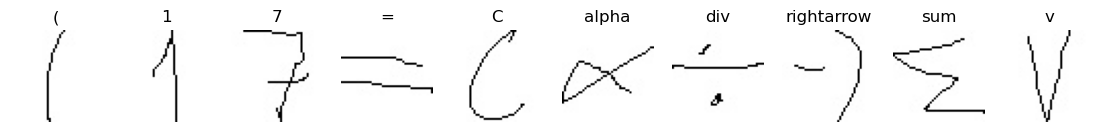

In [7]:
# Display one sample image per class
fig = plt.figure(figsize=(14, 3))
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)[0][0]
    ax = fig.add_subplot(1, len(class_names), i + 1)
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(class_name)
    ax.axis('off')
plt.show()

### Task 1: SVM Classifier

### Task 1a: SVM with Raw Pixel


### Raw pixel feature extraction

In [8]:
data_train_svm_raw = []
data_test_svm_raw  = []

for img_index in range(len(X_train)):
    image = (X_train[img_index])
    H = image.flatten() / 255.0
    data_train_svm_raw.append(H)

for img_index in range(len(X_test)):
    image = (X_test[img_index])
    H = image.flatten() / 255.0
    data_test_svm_raw.append(H)

print(np.shape(data_train_svm_raw))
print(np.shape(data_test_svm_raw))

(3500, 2025)
(1500, 2025)


### Train SVM Classifier using the training dataset

In [9]:
# Train SVM classifier on raw pixels
model_svm_raw = svm.SVC(kernel='rbf', C=100.0, random_state=42)
model_svm_raw.fit(data_train_svm_raw, y_train)

print("Train set Accuracy: {:.2f}".format(model_svm_raw.score(data_train_svm_raw, y_train)))

Train set Accuracy: 1.00


### Evaluation of trained SVM model on test dataset

In [10]:
# Evaluate on test dataset
predictions_svm_raw = model_svm_raw.predict(data_test_svm_raw)
accuracy_svm_raw = metrics.accuracy_score(y_test, predictions_svm_raw)
print("Accuracy on test dataset (SVM + Raw Pixels):", accuracy_svm_raw)

Accuracy on test dataset (SVM + Raw Pixels): 0.9453333333333334


[[151   9   0   0   4   0   0   0   0   0]
 [  7 130   0   2   0   0   2   2   7   2]
 [  0   0 151   0   0   2   1   0   1   0]
 [  0   3   0 140   3   1   3   3   0   1]
 [  2   0   1   3 136   0   0   0   1   0]
 [  0   0   0   0   0 138   0   0   0   3]
 [  0   0   0   1   0   0 141   0   1   0]
 [  0   2   0   0   0   1   0 155   0   0]
 [  0   0   0   2   0   3   0   0 127   0]
 [  0   1   0   2   0   1   0   0   5 149]]


Text(0.5, 1.0, 'Accuracy Score: 0.9453333333333334')

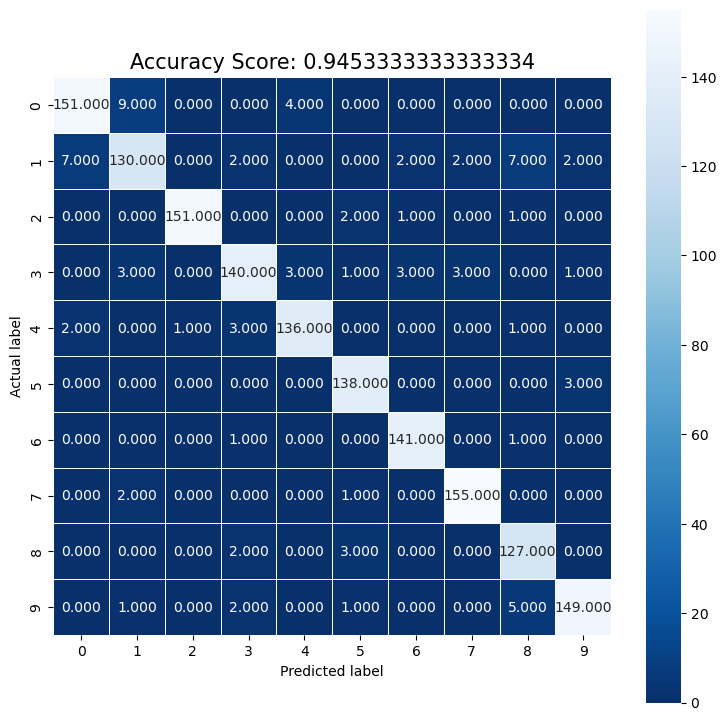

In [11]:
# Confusion matrix of SVM on raw pixels
cm = metrics.confusion_matrix(y_test, predictions_svm_raw)
print(cm)

plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_svm_raw)
plt.title(all_sample_title, size = 15)

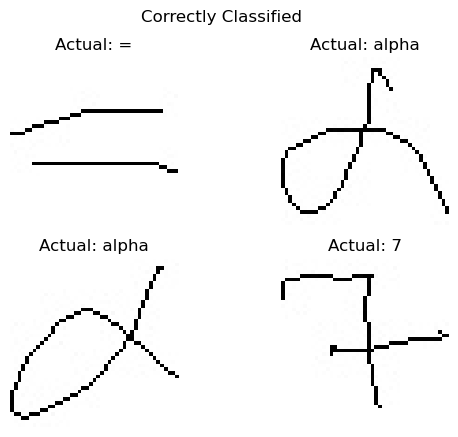

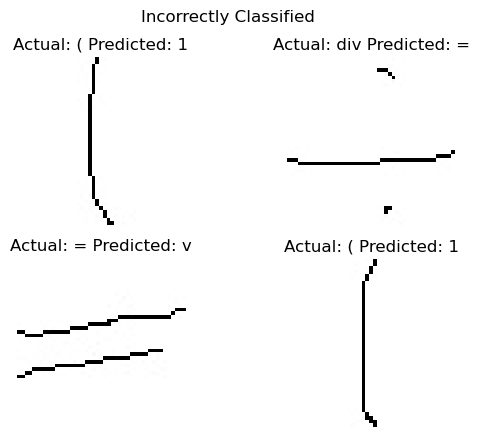

In [12]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predictions_svm_raw[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predictions_svm_raw[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predictions_svm_raw[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predictions_svm_raw[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predictions_svm_raw[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

### Task 1b: SVM with HoG Features

### Histogram-of-Oriented Gradient (HoG) feature extraction

In [13]:
# Extract HoG features for training dataset
print("Extracting features from training dataset...")
data_train_svm_hog = []
labels_train_svm_hog = []

for img_index in range(len(X_train)):
  # load the image, and extract HoG features
  image = (X_train[img_index])
  H = feature.hog(image, orientations=9, pixels_per_cell=(10, 10),
                  cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
  data_train_svm_hog.append(H)
  labels_train_svm_hog.append(y_train[img_index])

print(np.shape(data_train_svm_hog))
print(np.shape(labels_train_svm_hog))

Extracting features from training dataset...
(3500, 324)
(3500,)


### Training Classifier using SVM multiclass classifier

In [14]:
# Train SVM classifier on HoG features
model_svm_hog = svm.SVC(kernel='rbf', C=100.0, random_state=42)
model_svm_hog.fit(data_train_svm_hog, labels_train_svm_hog)

print("Train set Accuracy: {:.2f}".format(model_svm_hog.score(data_train_svm_hog, labels_train_svm_hog)))

Train set Accuracy: 1.00


### Evaluation of trained model on test dataset

### Experimental Results

In [15]:
# Extract HoG features for test dataset and evaluate
print("Extracting HoG features from test dataset...")
predict_test_svm_hog = []
data_test_svm_hog = []
labels_test_svm_hog = []

for img_ind in range(len(X_test)):
    # load the image, and extract HoG features
    img = X_test[img_ind]
    H = feature.hog(img, orientations=9, pixels_per_cell=(10, 10),
                    cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
    pred = model_svm_hog.predict(H.reshape(1, -1))[0]
    predict_test_svm_hog.append(pred)
    data_test_svm_hog.append(H)

    labels_test_svm_hog.append(y_test[img_ind])

print(np.shape(predict_test_svm_hog))
print(np.shape(labels_test_svm_hog))

Extracting HoG features from test dataset...
(1500,)
(1500,)


In [16]:
accuracy_svm_hog = metrics.accuracy_score(y_test, predict_test_svm_hog)
print("Accuracy on test dataset (SVM + HoG):", accuracy_svm_hog)

Accuracy on test dataset (SVM + HoG): 0.9686666666666667


[[151   7   0   0   6   0   0   0   0   0]
 [ 10 136   1   0   1   0   3   1   0   0]
 [  0   0 152   1   0   1   0   1   0   0]
 [  0   0   0 152   0   0   0   1   1   0]
 [  3   0   0   0 139   1   0   0   0   0]
 [  0   0   0   0   1 140   0   0   0   0]
 [  0   0   0   0   0   0 141   2   0   0]
 [  0   0   1   1   0   0   0 156   0   0]
 [  0   0   0   1   1   0   0   0 130   0]
 [  0   0   1   0   0   1   0   0   0 156]]


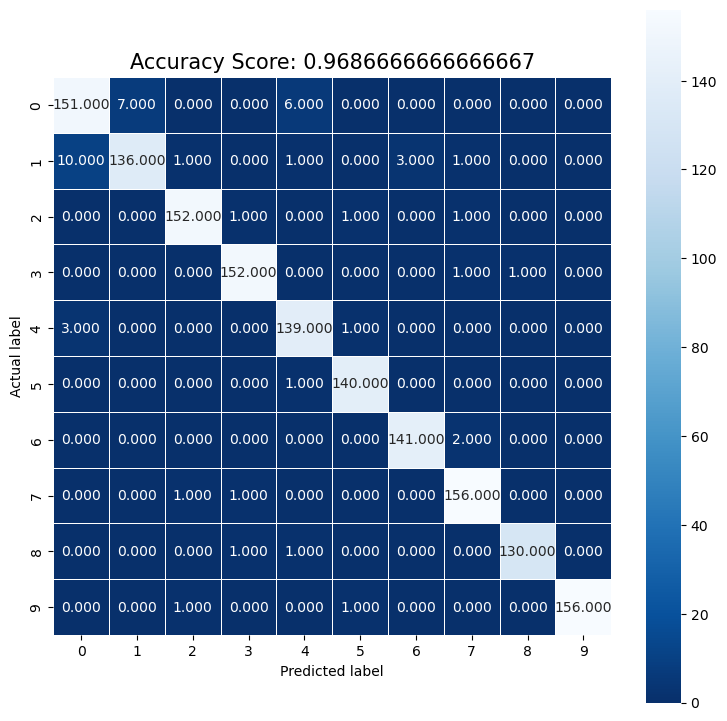

In [17]:
# Confusion matrix of SVM on HoG
cm = metrics.confusion_matrix(y_test, predict_test_svm_hog)
print(cm)

plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_svm_hog)
plt.title(all_sample_title, size = 15);

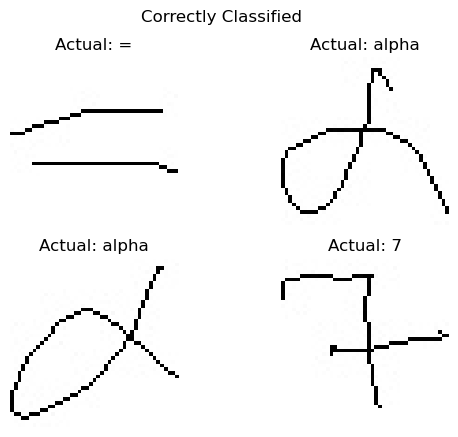

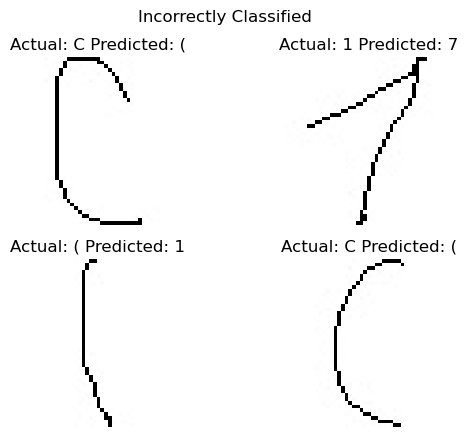

In [18]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predict_test_svm_hog[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predict_test_svm_hog[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predict_test_svm_hog[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predict_test_svm_hog[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predict_test_svm_hog[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

### Task 1c: SVM with LBP feature

### Local Binary Patterns (LBP) class definition for LBP feature extraction

In [19]:
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius

	def LBPfeatures(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints,
			self.radius, method="uniform")
    # Form the histogram
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, self.numPoints + 3),
			range=(0, self.numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return hist

**LBP feature extraction for the whole training dataset**

In [20]:
desc = LocalBinaryPatterns(24, 8)
data_train_svm_lbp = []
labels_train_svm_lbp = []

for img_index in range(len(X_train)):
	image = (X_train[img_index])
	hist = desc.LBPfeatures(image)

	labels_train_svm_lbp.append(y_train[img_index])
	data_train_svm_lbp.append(hist)

### Train SVM Classifier using the training dataset

In [21]:
model_svm_lbp = svm.SVC(kernel='rbf',C=100.0, random_state=42)
model_svm_lbp.fit(data_train_svm_lbp, labels_train_svm_lbp)

print(np.shape(data_train_svm_lbp))
print(np.shape(labels_train_svm_lbp))

(3500, 26)
(3500,)


In [22]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model_svm_lbp.score(data_train_svm_lbp,labels_train_svm_lbp)))

Train set Accuracy: 0.68


### Evaluation of trained SVM model on test dataset

In [23]:
predictions_svm_lbp=[]
predict_label_svm_lbp=[]
# Exract LBP features for each test sample and classify it with the trained SVM classifier
for im_index in range(len(X_test)):
  imag = X_test[im_index]
  # Extract LBP feature
  histo = desc.LBPfeatures(imag)
  prediction_svm_lbp = model_svm_lbp.predict(histo.reshape(1, -1))[0]

  predictions_svm_lbp.append(prediction_svm_lbp)
  predict_label_svm_lbp.append(y_test[im_index])

In [24]:
accuracy_svm_lbp = metrics.accuracy_score(y_test, predictions_svm_lbp)
print("Accuracy on test dataset:",accuracy_svm_lbp)

Accuracy on test dataset: 0.6713333333333333


[[140  13   3   0   6   0   1   1   0   0]
 [ 25  92  12   5   0   2   1   6   3   6]
 [  5  14  66  11   2   4  15   8   2  28]
 [  3  17   2  98  19   3   1   0   5   6]
 [  5   0   2   6 116   0   0   0   4  10]
 [  0   2   4   1   0 121   0   1   3   9]
 [  2  16   7   0   0   0 106   5   1   6]
 [ 15  21   6   2   3   0  17  85   0   9]
 [  1   0   4   4  11  19   1   2  87   3]
 [  1   6   5   8   2  21   0   6  13  96]]


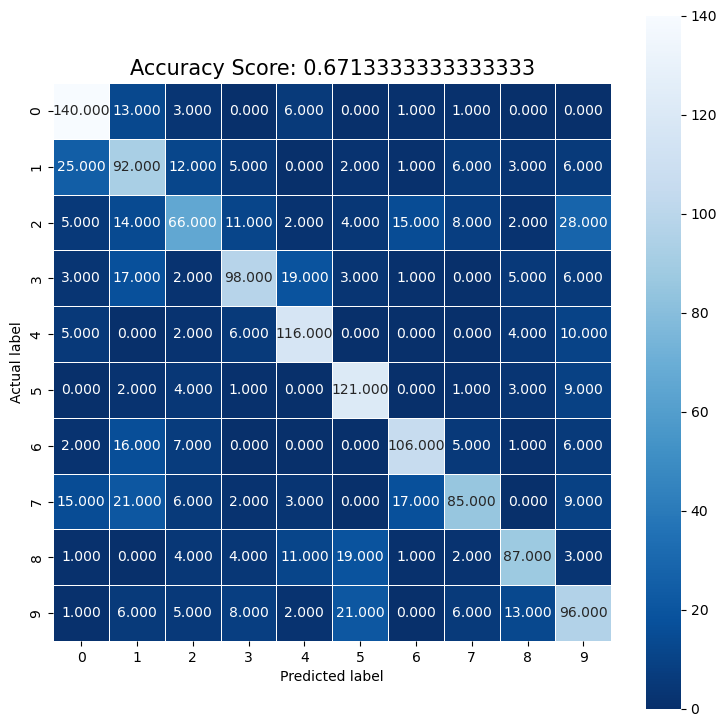

In [25]:
# Confusion matrix of SVM with LBP
cm = metrics.confusion_matrix(y_test, predictions_svm_lbp)
print(cm)

plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_svm_lbp)
plt.title(all_sample_title, size = 15);

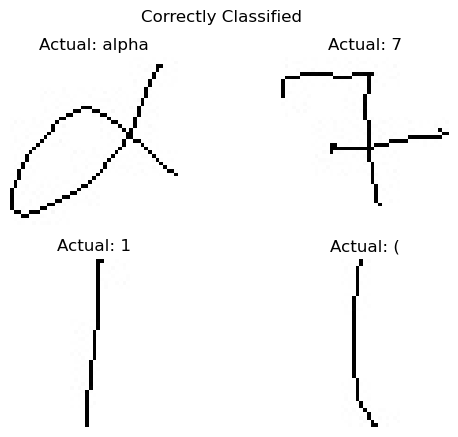

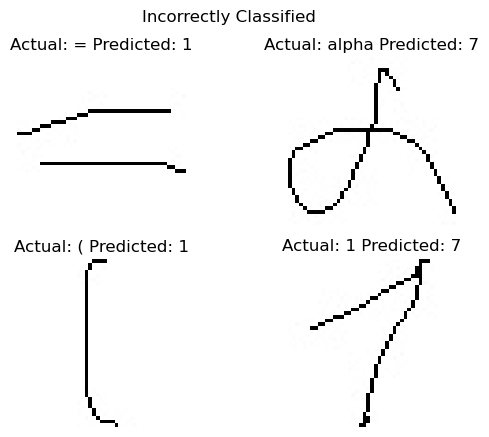

In [26]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predictions_svm_lbp[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predictions_svm_lbp[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predictions_svm_lbp[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predictions_svm_lbp[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predictions_svm_lbp[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

### SVM result

In [27]:
print("SVM + Raw Pixels Accuracy: {:.2f}".format(accuracy_svm_raw))
print("SVM + HoG         Accuracy: {:.2f}".format(accuracy_svm_hog))
print("SVM + LBP         Accuracy: {:.2f}".format(accuracy_svm_lbp))

SVM + Raw Pixels Accuracy: 0.95
SVM + HoG         Accuracy: 0.97
SVM + LBP         Accuracy: 0.67


## Task 2: Artificial Neural Network (ANN) Classifier

Train an ANN using Raw Pixels, HoG, and LBP.

### Feature Extraction for ANN

In [28]:
# Extract Raw Pixel features for ANN
print("Extracting Raw Pixel features...")
data_train_ann_raw = []
data_test_ann_raw  = []

for img_index in range(len(X_train)):
    image = X_train[img_index]
    H = image.flatten() / 255.0
    data_train_ann_raw.append(H)

for img_index in range(len(X_test)):
    image = X_test[img_index]
    H = image.flatten() / 255.0
    data_test_ann_raw.append(H)

print(np.shape(data_train_ann_raw))
print(np.shape(data_test_ann_raw))

Extracting Raw Pixel features...
(3500, 2025)
(1500, 2025)


In [29]:
# Extract HoG features for ANN
print("Extracting HoG features...")
data_train_ann_hog = []
data_test_ann_hog  = []
labels_train_ann_hog = []
labels_test_ann_hog  = []

for img_index in range(len(X_train)):
    image = X_train[img_index]
    H = feature.hog(image, orientations=9, pixels_per_cell=(10, 10),
                    cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
    data_train_ann_hog.append(H)
    labels_train_ann_hog.append(y_train[img_index])

for img_index in range(len(X_test)):
    image = X_test[img_index]
    H = feature.hog(image, orientations=9, pixels_per_cell=(10, 10),
                    cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
    data_test_ann_hog.append(H)
    labels_test_ann_hog.append(y_test[img_index])

print(np.shape(data_train_ann_hog))
print(np.shape(labels_train_ann_hog))
print(np.shape(data_test_ann_hog))
print(np.shape(labels_test_ann_hog))

Extracting HoG features...
(3500, 324)
(3500,)
(1500, 324)
(1500,)


In [30]:
# Extract LBP features for ANN
print("Extracting LBP features...")
data_train_ann_lbp = []
data_test_ann_lbp  = []
lables_train_ann_lbp = []
labels_test_ann_lbp  = []

for img_index in range(len(X_train)):
    image = X_train[img_index]
    hist = desc.LBPfeatures(image)
    data_train_ann_lbp.append(hist)
    lables_train_ann_lbp.append(y_train[img_index])

for img_index in range(len(X_test)):
    imag = X_test[img_index]
    histo = desc.LBPfeatures(imag)
    data_test_ann_lbp.append(histo)
    labels_test_ann_lbp.append(X_test[img_index])

print(np.shape(data_train_ann_lbp))
print(np.shape(lables_train_ann_lbp))
print(np.shape(data_train_ann_lbp))
print(np.shape(labels_test_ann_lbp))

Extracting LBP features...
(3500, 26)
(3500,)
(3500, 26)
(1500, 45, 45)


### ANN with Raw Pixel Features

In [31]:
# Design the ANN model for Raw Pixels
model_ann_raw = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=[np.shape(data_train_ann_raw)[1]]),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_ann_raw.compile(optimizer=tf.optimizers.Adam(),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

H_raw = model_ann_raw.fit(np.array(data_train_ann_raw), y_train, epochs=30)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1529 - loss: 2.3834
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2820 - loss: 2.0614
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4646 - loss: 1.6436
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6054 - loss: 1.2682
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6560 - loss: 1.0628
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7520 - loss: 0.8250
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7789 - loss: 0.7245
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8140 - loss: 0.6406
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8543 - loss: 0.5206
Epoch 10/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8609 - loss: 0.4884
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8534 - loss: 0.4920
Epoch 12/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

In [32]:
model_ann_raw.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2025)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       518,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,658,528 (6.33 MB)

 Trainable params: 552,842 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,105,686 (4.22 MB)

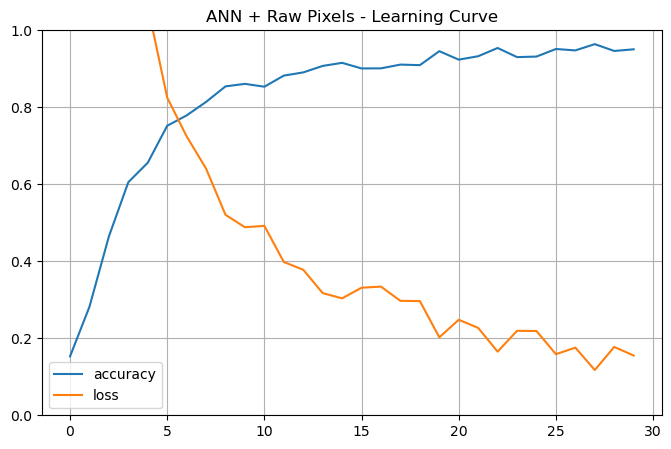

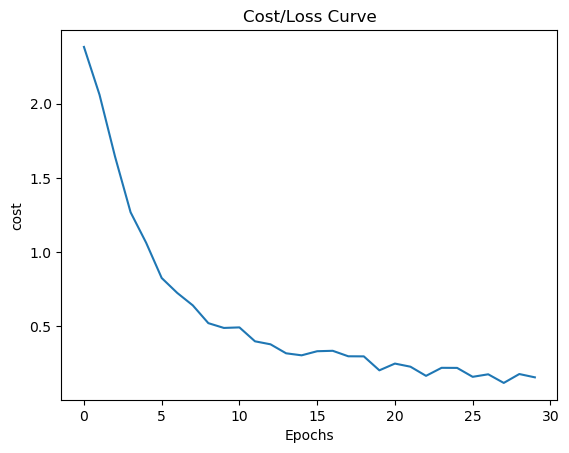

In [33]:
import pandas as pd
pd.DataFrame(H_raw.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("ANN + Raw Pixels - Learning Curve")
plt.show()

plt.plot(H_raw.history['loss'])
plt.ylabel('cost')
plt.xlabel('Epochs')
plt.title("Cost/Loss Curve")
plt.show()

In [34]:
# Evaluate ANN on Raw Pixels on test dataset
model_ann_raw.evaluate(np.array(data_test_ann_raw), y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8907 - loss: 0.4323


[0.43231502175331116, 0.890666663646698]

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy on test dataset: 0.8906666666666667
[[118  26   0   0   2   0   2   0  15   1]
 [  5 127   2   1   2   5   4   2   4   0]
 [  0   1 150   0   0   1   2   0   0   1]
 [  0   0   1 124   1   3   6   1  16   2]
 [  1   0   0   1 133   2   0   0   4   2]
 [  0   1   3   0   1 132   1   0   2   1]
 [  0   0   0   1   0   0 142   0   0   0]
 [  0   1   1   2   0   0   6 148   0   0]
 [  0   0   0   5   2   1   0   0 124   0]
 [  0   5   3   0   0   8   1   0   3 138]]


Text(0.5, 1.0, 'Accuracy Score: 0.8906666666666667')

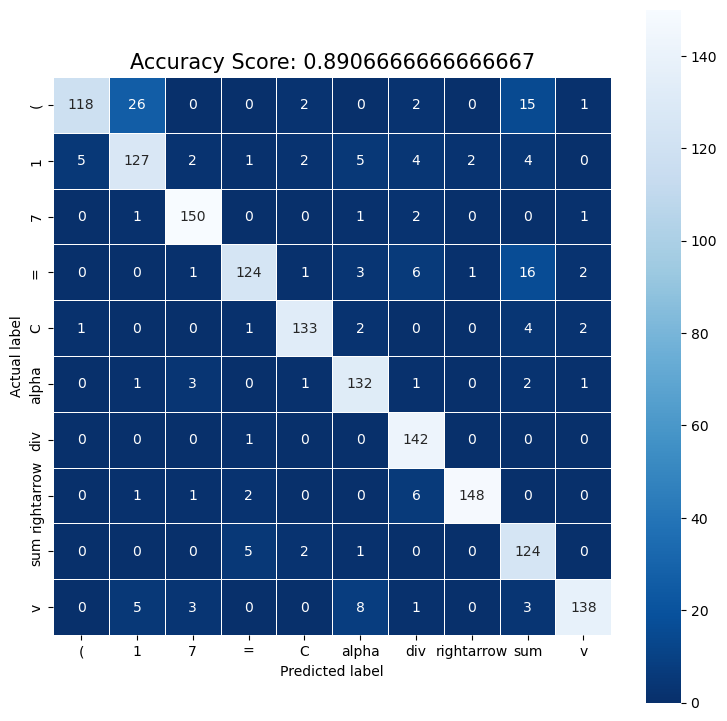

In [35]:
# Confusion matrix of ANN on Raw Pixels
predictions_ann_raw = np.argmax(model_ann_raw.predict(np.array(data_test_ann_raw)), axis=1)
accuracy_ann_raw = metrics.accuracy_score(y_test, predictions_ann_raw)
print("Accuracy on test dataset:", accuracy_ann_raw)

cm = metrics.confusion_matrix(y_test, predictions_ann_raw)
print(cm)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap="Blues_r",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_ann_raw)
plt.title(all_sample_title, size=15)

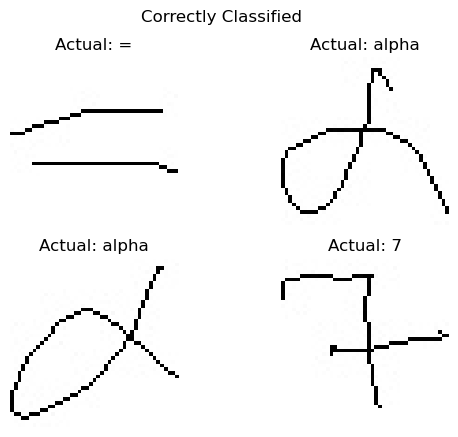

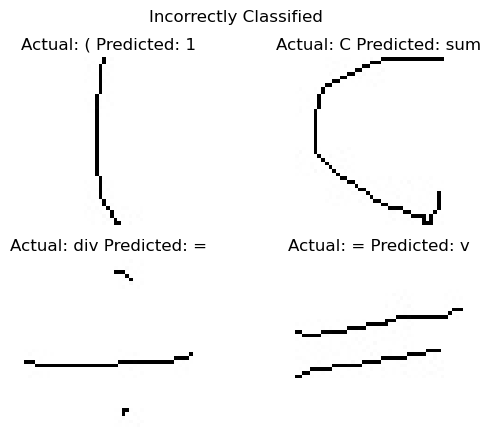

In [36]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predictions_ann_raw[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predictions_ann_raw[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predictions_ann_raw[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predictions_ann_raw[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predictions_ann_raw[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

### Task 2b: ANN with HoG Features

In [37]:
# Design the ANN model for HoG features
model_ann_hog = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=[np.shape(data_train_ann_hog)[1]]),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_ann_hog.compile(optimizer=tf.optimizers.Adam(),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

H_hog = model_ann_hog.fit(np.array(data_train_ann_hog), y_train, epochs=30)

Epoch 1/30


/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7926 - loss: 0.8405
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9429 - loss: 0.2138
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9520 - loss: 0.1480
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9677 - loss: 0.1127
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9769 - loss: 0.0890
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9831 - loss: 0.0699
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0600
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9854 - loss: 0.0483
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9891 - loss: 0.0417
Epoch 10/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.0366
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9909 - loss: 0.0360
Epoch 12/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy

In [38]:
model_ann_hog.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 324)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        83,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,160 (1.34 MB)

 Trainable params: 117,386 (458.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 234,774 (917.09 KB)

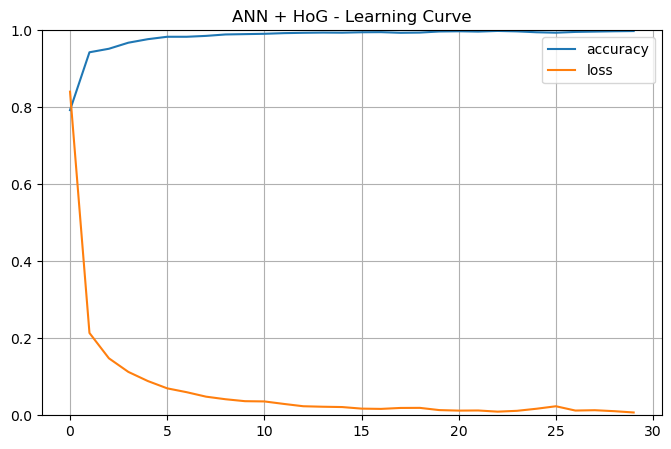

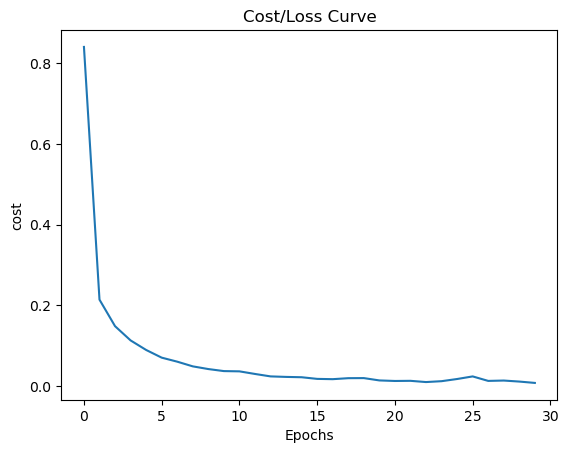

In [39]:
pd.DataFrame(H_hog.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("ANN + HoG - Learning Curve")
plt.show()

plt.plot(H_hog.history['loss'])
plt.ylabel('cost')
plt.xlabel('Epochs')
plt.title("Cost/Loss Curve")
plt.show()


In [40]:
# Evaluate ANN on HoG on test dataset
model_ann_hog.evaluate(np.array(data_test_ann_hog), y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9660 - loss: 0.1596


[0.15956543385982513, 0.9660000205039978]

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy on test dataset: 0.966
[[141  15   0   0   6   0   0   0   0   2]
 [  8 137   1   1   1   1   2   0   0   1]
 [  0   1 153   1   0   0   0   0   0   0]
 [  0   0   0 152   0   0   0   2   0   0]
 [  1   0   0   0 140   0   0   0   0   2]
 [  0   0   0   0   1 140   0   0   0   0]
 [  0   0   0   0   0   0 143   0   0   0]
 [  0   0   1   1   0   0   0 156   0   0]
 [  0   0   0   1   0   0   0   0 131   0]
 [  0   1   1   0   0   0   0   0   0 156]]


Text(0.5, 1.0, 'Accuracy Score: 0.966')

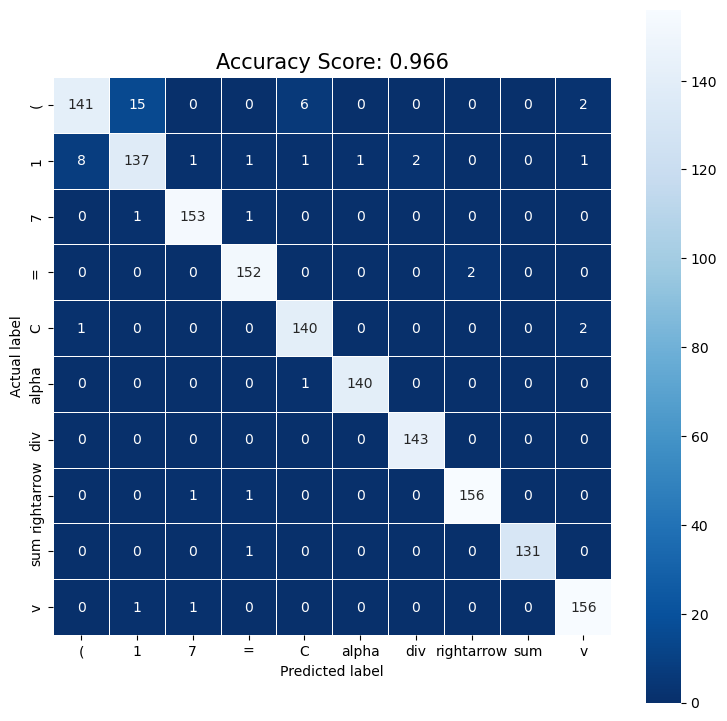

In [41]:
# Confusion matrix of ANN on HoG
predictions_ann_hog = np.argmax(model_ann_hog.predict(np.array(data_test_ann_hog)), axis=1)
accuracy_ann_hog = metrics.accuracy_score(y_test, predictions_ann_hog)
print("Accuracy on test dataset:", accuracy_ann_hog)

cm = metrics.confusion_matrix(y_test, predictions_ann_hog)
print(cm)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap="Blues_r",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_ann_hog)
plt.title(all_sample_title, size=15)

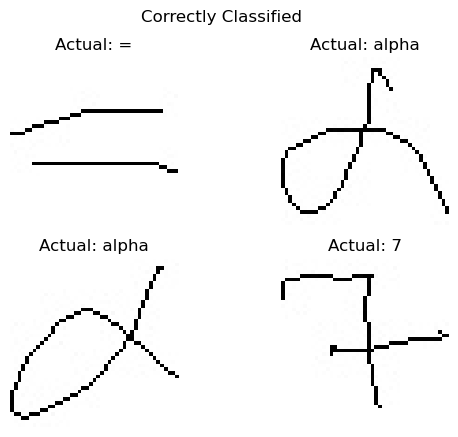

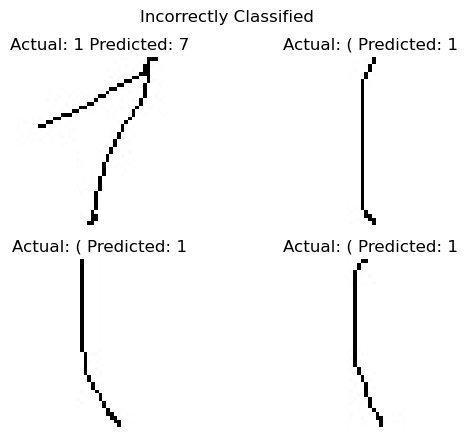

In [42]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predictions_ann_hog[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predictions_ann_hog[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predictions_ann_hog[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predictions_ann_hog[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predictions_ann_hog[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

In [43]:
# Design the ANN model for LBP features
model_ann_lbp = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=[np.shape(data_train_ann_lbp)[1]]),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_ann_lbp.compile(optimizer=tf.optimizers.Adam(),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

H_lbp = model_ann_lbp.fit(np.array(data_train_ann_lbp), y_train, epochs=30)

Epoch 1/30


/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1831 - loss: 2.2030
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2723 - loss: 1.9406
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3289 - loss: 1.8110
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3609 - loss: 1.7122
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3834 - loss: 1.6503
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3983 - loss: 1.6028
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4140 - loss: 1.5720
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4311 - loss: 1.5332
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4403 - loss: 1.4994
Epoch 10/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4549 - loss: 1.4694
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4640 - loss: 1.4404
Epoch 12/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [44]:
model_ann_lbp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,296 (481.63 KB)

 Trainable params: 41,098 (160.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,198 (321.09 KB)

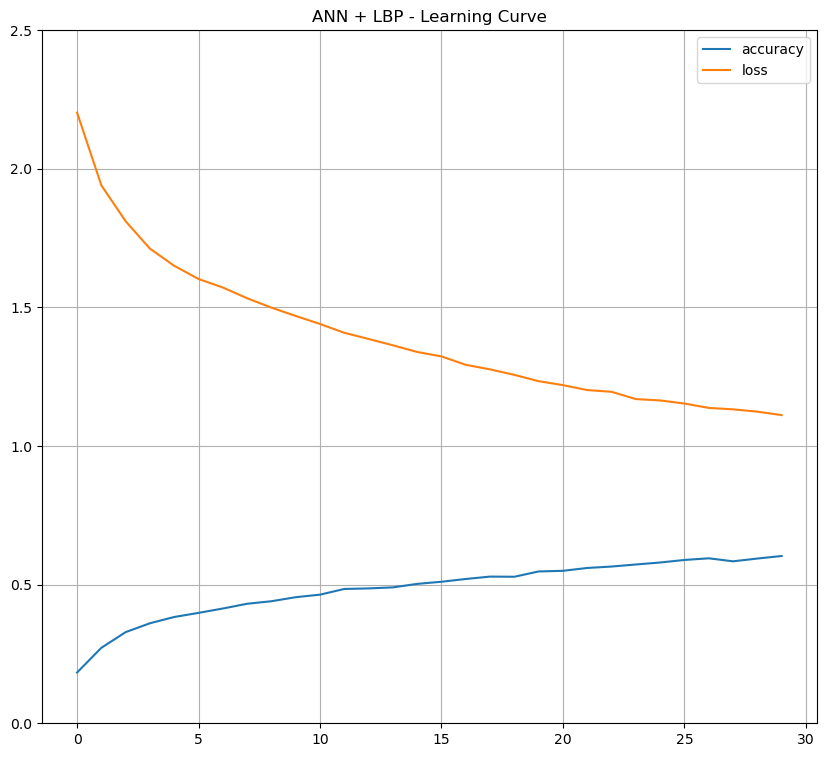

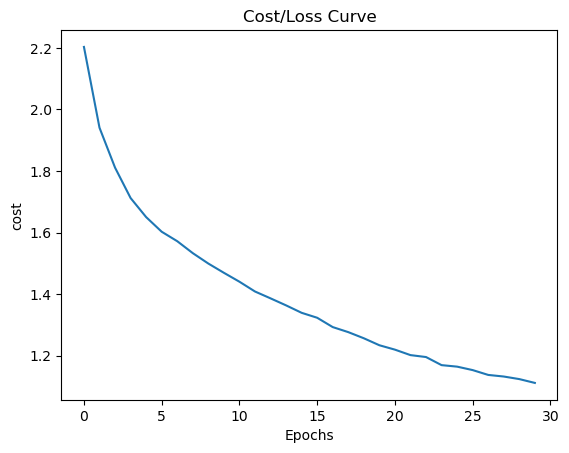

In [45]:
pd.DataFrame(H_lbp.history).plot(figsize=(10, 9))
plt.grid(True)
plt.gca().set_ylim(0, 2.5)
plt.title("ANN + LBP - Learning Curve")
plt.show()

plt.plot(H_lbp.history['loss'])
plt.ylabel('cost')
plt.xlabel('Epochs')
plt.title("Cost/Loss Curve")
plt.show()

In [46]:
# Evaluate ANN on LBP on test dataset
model_ann_lbp.evaluate(np.array(data_test_ann_lbp), y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5687 - loss: 1.1419


[1.1418596506118774, 0.5686666369438171]

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy on test dataset: 0.5686666666666667
[[124  22   0   4   5   0   1   8   0   0]
 [ 23  67  12  13   0   7   2  21   1   6]
 [  4   4  43  20   0   8  23  23   4  26]
 [  1  17   1 101  15  11   2   0   3   3]
 [  4   0   3  20 101   1   0   0   8   6]
 [  0   2   3   0   0 124   0   2   5   5]
 [  2  13  14   1   0   1 105   6   0   1]
 [ 13  11  25   7   3   2  16  76   2   3]
 [  0   0   3   4  16  35   0   1  70   3]
 [  0   2  20  19   2  56   0   7  10  42]]


Text(0.5, 1.0, 'Accuracy Score: 0.5686666666666667')

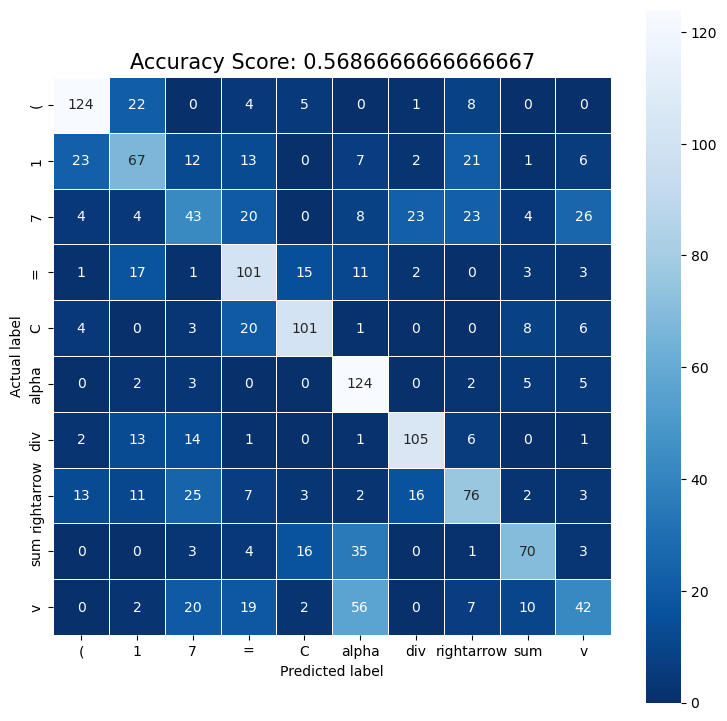

In [47]:
# Confusion matrix of ANN on LBP
predictions_ann_lbp = np.argmax(model_ann_lbp.predict(np.array(data_test_ann_lbp)), axis=1)
accuracy_ann_lbp = metrics.accuracy_score(y_test, predictions_ann_lbp)
print("Accuracy on test dataset:", accuracy_ann_lbp)

cm = metrics.confusion_matrix(y_test, predictions_ann_lbp)
print(cm)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap="Blues_r",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_ann_lbp)
plt.title(all_sample_title, size=15)

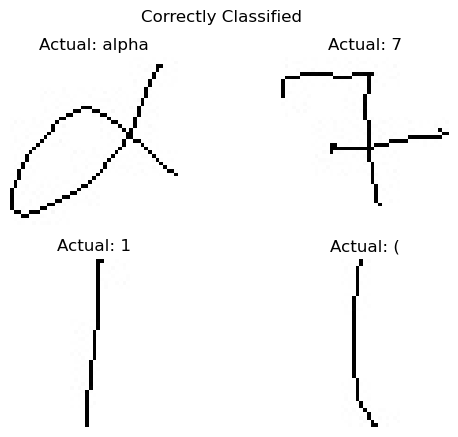

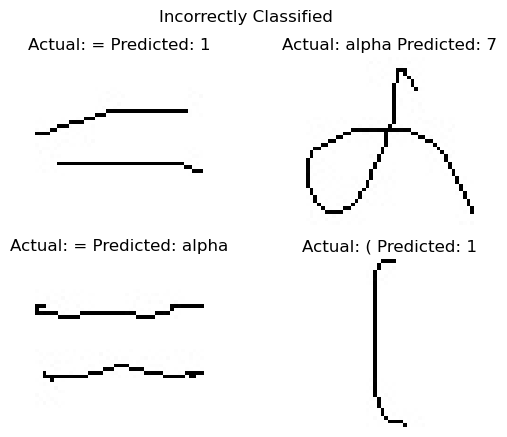

In [48]:
correct   = []
incorrect = []

for i in range(len(y_test)):
    if predictions_ann_lbp[i] == y_test[i]:
        correct.append(i)
    else:
        incorrect.append(i)

## Display correctly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[correct[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[correct[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[correct[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[correct[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[correct[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[correct[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[correct[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[correct[3]]])
ax4.axis("off")
plt.suptitle("Correctly Classified")
plt.show()

## Display incorrectly classified
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(X_test[incorrect[0]], cmap="gray")
ax1.set_title("Actual: " + class_names[y_test[incorrect[0]]] + " Predicted: " + class_names[predictions_ann_lbp[incorrect[0]]])
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(X_test[incorrect[1]], cmap="gray")
ax2.set_title("Actual: " + class_names[y_test[incorrect[1]]] + " Predicted: " + class_names[predictions_ann_lbp[incorrect[1]]])
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(X_test[incorrect[2]], cmap="gray")
ax3.set_title("Actual: " + class_names[y_test[incorrect[2]]] + " Predicted: " + class_names[predictions_ann_lbp[incorrect[2]]])
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(X_test[incorrect[3]], cmap="gray")
ax4.set_title("Actual: " + class_names[y_test[incorrect[3]]] + " Predicted: " + class_names[predictions_ann_lbp[incorrect[3]]])
ax4.axis("off")
plt.suptitle("Incorrectly Classified")
plt.show()

### ANN Result

In [49]:
print("ANN + Raw Pixels Accuracy: {:.2f}".format(accuracy_ann_raw))
print("ANN + HoG         Accuracy: {:.2f}".format(accuracy_ann_hog))
print("ANN + LBP         Accuracy: {:.2f}".format(accuracy_ann_lbp))

ANN + Raw Pixels Accuracy: 0.89
ANN + HoG         Accuracy: 0.97
ANN + LBP         Accuracy: 0.57


### Comparative Study

In [50]:
# Summary table comparing all classifier and feature combinations
print("Classifier | Feature     | Accuracy")
print("-" * 40)
print("SVM        | Raw Pixels  | {:.2f}".format(accuracy_svm_raw))
print("SVM        | HoG         | {:.2f}".format(accuracy_svm_hog))
print("SVM        | LBP         | {:.2f}".format(accuracy_svm_lbp))
print("-" * 40)
print("ANN        | Raw Pixels  | {:.2f}".format(accuracy_ann_raw))
print("ANN        | HoG         | {:.2f}".format(accuracy_ann_hog))
print("ANN        | LBP         | {:.2f}".format(accuracy_ann_lbp))

Classifier | Feature     | Accuracy
----------------------------------------
SVM        | Raw Pixels  | 0.95
SVM        | HoG         | 0.97
SVM        | LBP         | 0.67
----------------------------------------
ANN        | Raw Pixels  | 0.89
ANN        | HoG         | 0.97
ANN        | LBP         | 0.57


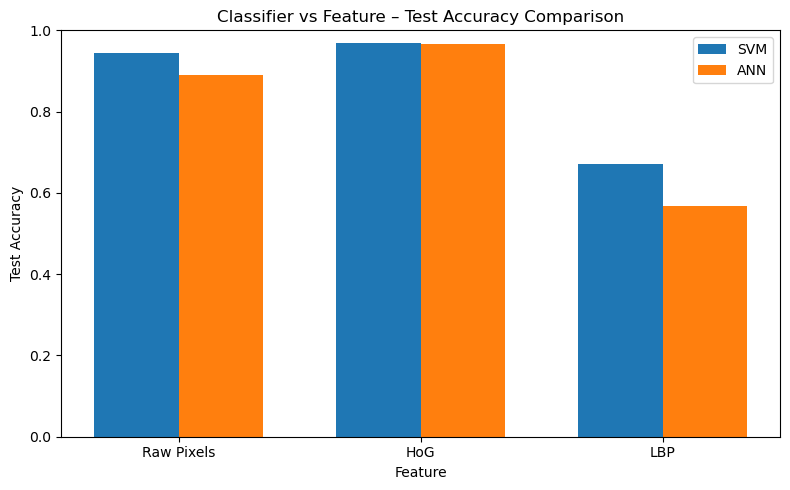

In [51]:
# Bar chart comparing all results
features = ['Raw Pixels', 'HoG', 'LBP']
svm_accs = [accuracy_svm_raw, accuracy_svm_hog, accuracy_svm_lbp]
ann_accs = [accuracy_ann_raw, accuracy_ann_hog, accuracy_ann_lbp]

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, svm_accs, width, label='SVM')
ax.bar(x + width/2, ann_accs, width, label='ANN')
ax.set_xlabel('Feature')
ax.set_ylabel('Test Accuracy')
ax.set_title('Classifier vs Feature – Test Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()